# Analisis General

El siguiente planteamiento tecnico responde a la necesidad de implementar una solucion escalable basada en la nube que permita integrar informacion proveniente de diversas fuentes, gestionar grandes volumenes de datos en crecimiento constante y permitir una mejora en la toma de decisiones con informacion confiable y actualizada.

## Descripcion general de la solucion

Se opto por diseñar una arquitectura de procesamiento ***`Lambda`*** ya que es una solución híbrida que combina procesamiento en batch y en streaming, lo que permite en este caso hacer un monitoreo del clima en tiempo real y un analisis de la evolucion historica mas exhaustiva. Ademas se opto por la arquitectura de trabajo ***`Medallon`*** y una arquitectura de almacenamiento del tipo ***`Data Lake`***, separando los datos en las capas de bronze, silver y gold.

El proceso cuenta con una carga inicial de datos historicos realizada con scripts de *Python*, y una carga calendarizada desde un conector de *Airbyte* hacia una API de clima (*Openweather*). Los datos se cargan inicialmente en el bucket de Bronze. Luego son procesados en batch mediante scripts de *Apache Spark* generando particiones por region y fecha. Finalmente son consumidos desde *AWS Athena* utilizando el catalogo de AWS Glue para consultar los archivos mediante SQL estandar. 

Toda la arquitectura principal esta orquestada por *Apache Airflow*. Tambien se implemento un flujo CI/CD con *GitHub Actions*. Como implementacion adicional se utiliza *Apache Kafka* para complementar la obtencion de datos en streaming.

Las capas del Data Lake corresponden a buckets en AWS S3. Tanto Apache Airflow como Apache Spark y Apache Kafka corren en contenedores docker separados dentro de distintas instancias de AWS EC2. De esta forma queda toda la infraestructura montada en AWS.

### Diagrama de la solucion

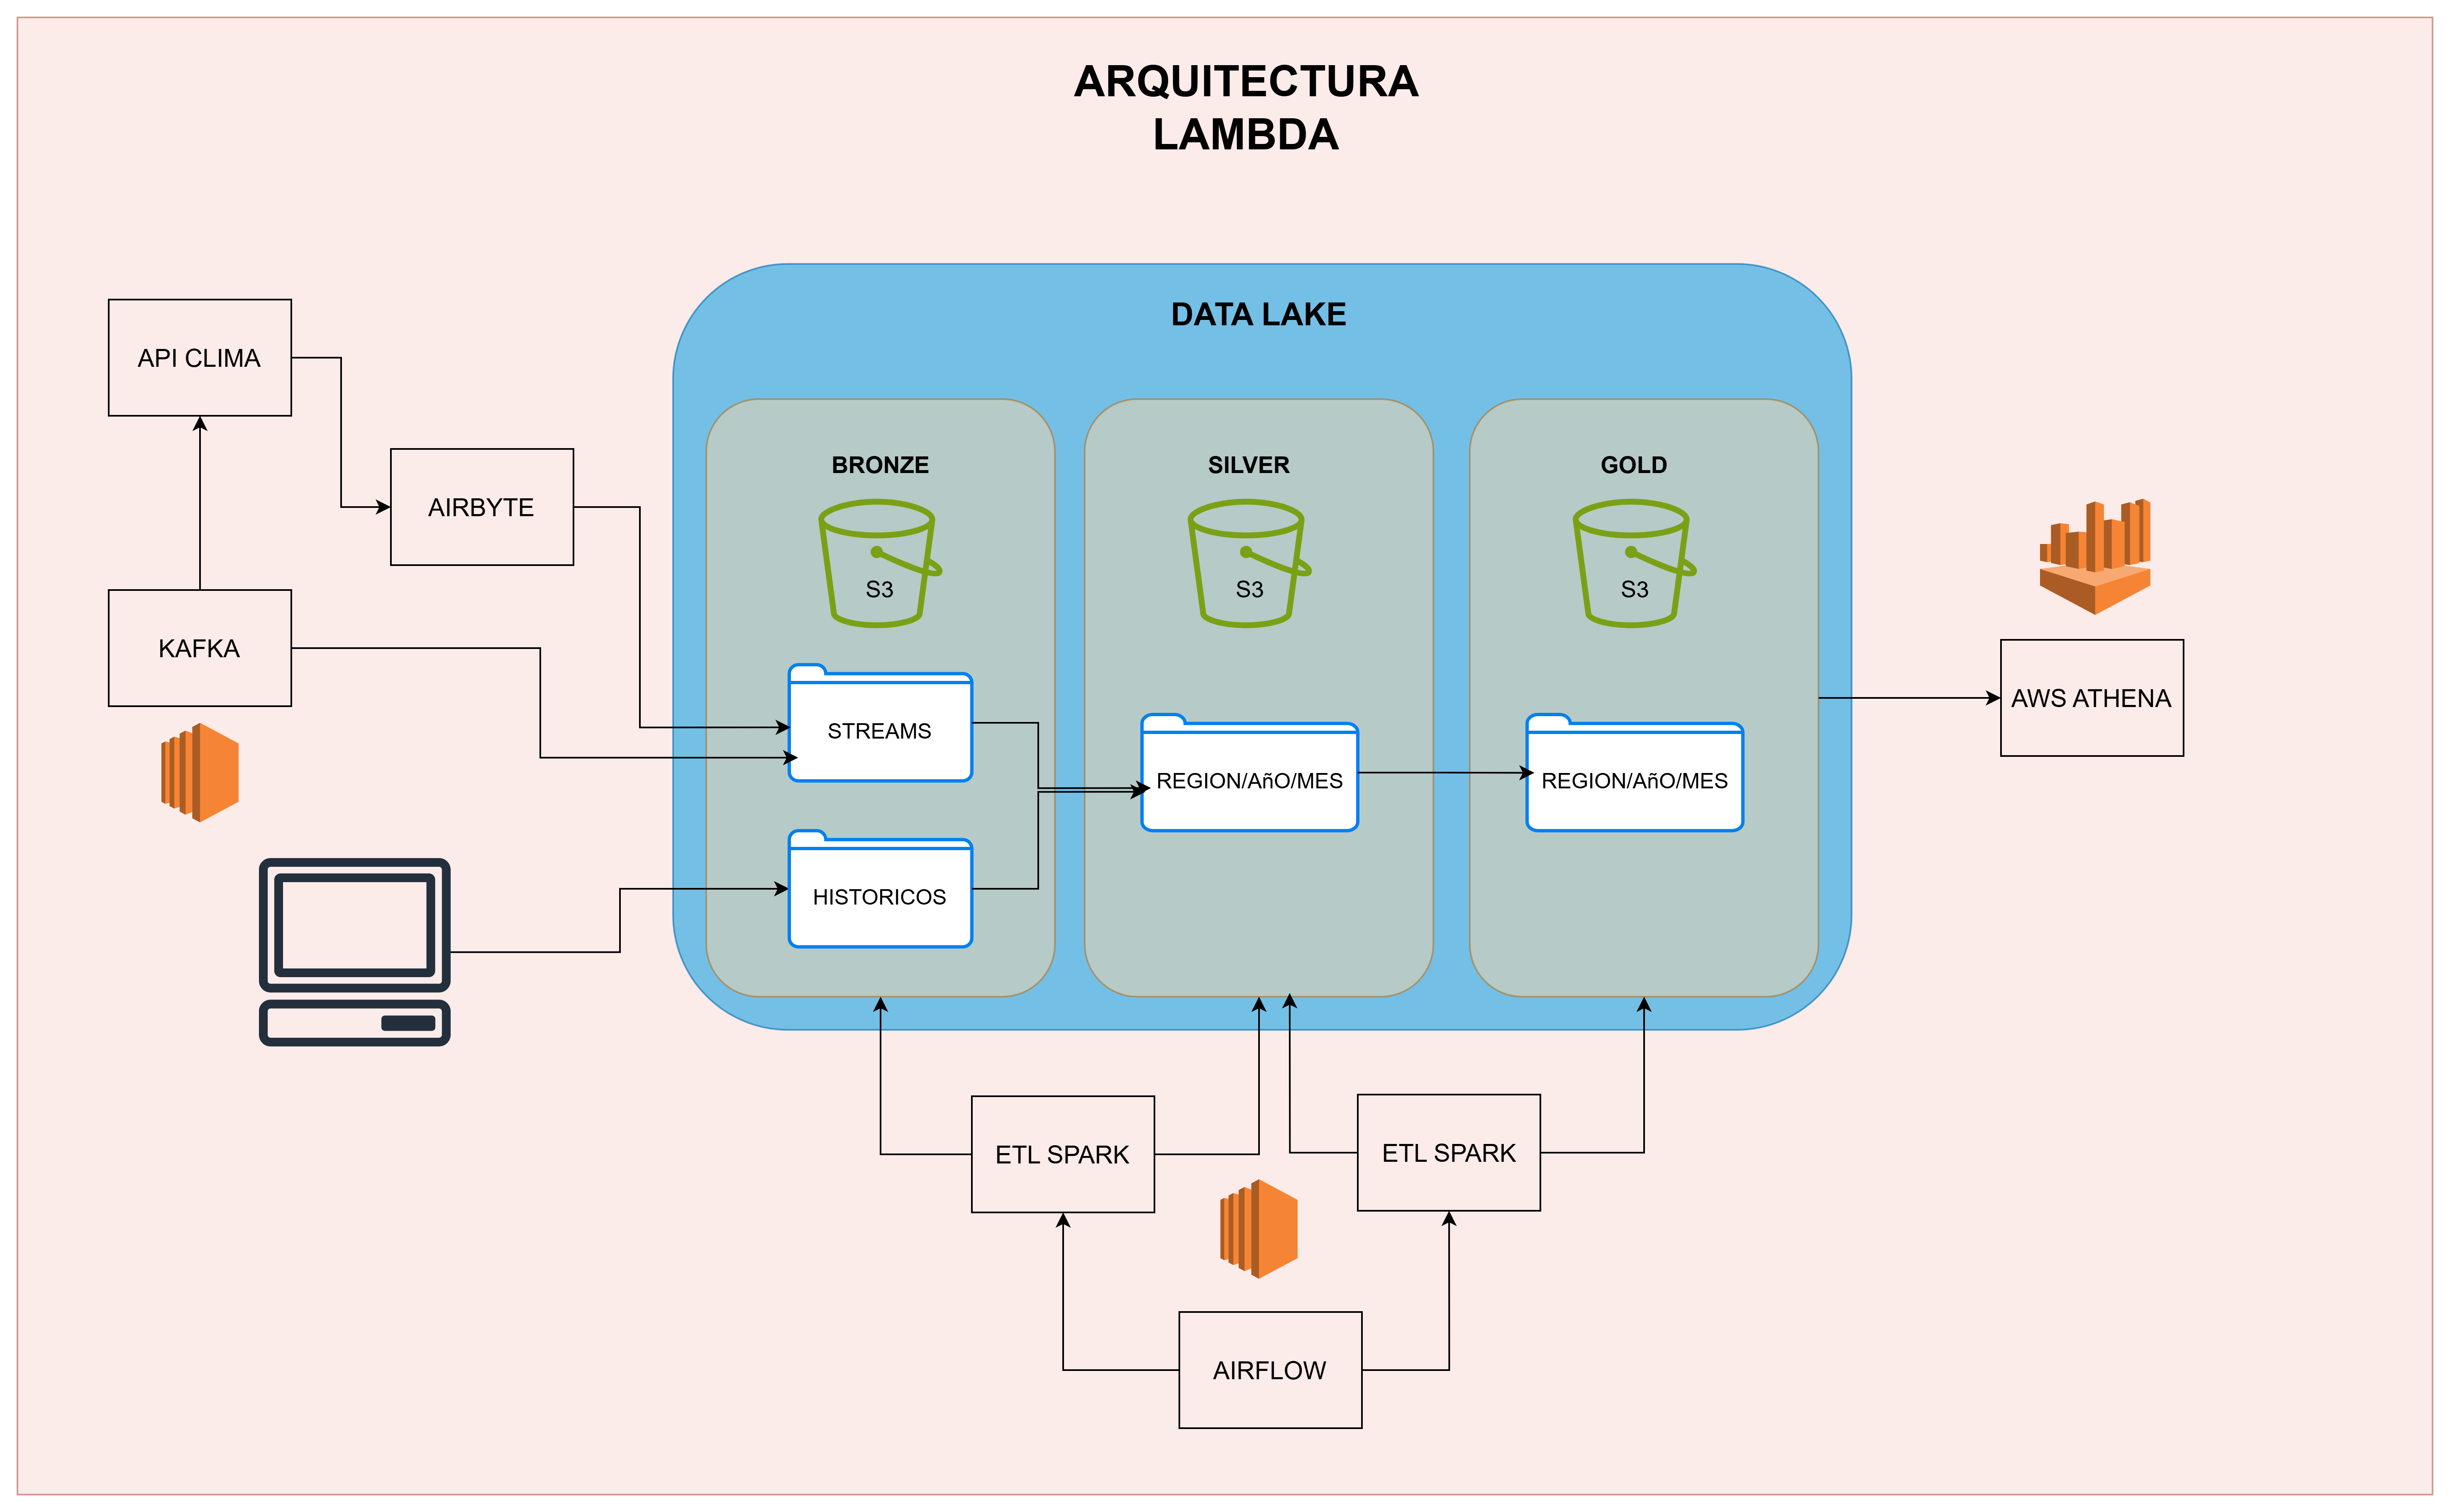